<a href="https://colab.research.google.com/github/pabloecheg/Unsupervised-Learning/blob/main/codigo_parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Description of Columns:

* TYPE: Type of the house.

* PRICE: Price of the house.

* BEDS: Number of bedrooms.

* BATH: Number of bathrooms.

* PROPERTYSQFT: Square footage of the property.

* LATITUDE: Latitude coordinate of the house.

* LONGITUDE: Longitude coordinate of the house.

In [ ]:
from google.colab import drive # conexión con drive
drive.mount('/content/drive')
import pandas as pd # Manejo de Data Frame
import numpy as np # Manejo matricial
import warnings # Omitir warnings
warnings.filterwarnings("ignore") # Ignorar warning (me estresan los warnings >:|)
# librerías para Gráficos
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
# Librerías para clustering
from sklearn.cluster import (KMeans, AgglomerativeClustering)
from scipy.cluster.hierarchy import dendrogram,  linkage # Dendograma
# Score de silueta
from sklearn.metrics import silhouette_score, pairwise_distances_argmin_min
from sklearn.preprocessing import StandardScaler # estandarizar variables.

Mounted at /content/drive


In [ ]:
datos = pd.read_csv("/content/drive/MyDrive/APRENDIZAJE NO SUPERVISADO/Parcial 1/NY-House-Dataset.csv")
datos= datos[ datos["PRICE"]< 10**7]
datos=datos[datos["BEDS"] <20]
datos=datos[datos["BATH"] <20]
datos["TYPE"]= datos["TYPE"].replace({"Condop for sale": "Condo for sale",
                                      'Multi-family home for sale': "House for sale",
                                      # "Townhouse for sale":"House for sale",
                                      'Pending':np.nan, 'Contingent':np.nan})
categorias_drop = [ 'Land for sale', 'For sale', "House for sale",
                   'Foreclosure', 'Coming Soon',
                   'Mobile house for sale',"Townhouse for sale"]
datos["TYPE"] = datos["TYPE"].replace( categorias_drop, "Other")
datos = datos[~datos["TYPE"].isin(categorias_drop)]

In [ ]:
datos.isna().sum()

,0
BROKERTITLE,0
TYPE,327
PRICE,0
BEDS,0
BATH,0
PROPERTYSQFT,0
ADDRESS,0
STATE,0
MAIN_ADDRESS,0
ADMINISTRATIVE_AREA_LEVEL_2,0


In [ ]:
datos = datos.dropna()

In [ ]:
keep_columns =['TYPE', 'PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']
data1 = datos[keep_columns]
data1.head()

,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
0,Condo for sale,315000,2,2.0,1400.000000,40.761255,-73.974483
2,Other,260000,4,2.0,2015.000000,40.541805,-74.196109
3,Condo for sale,69000,3,1.0,445.000000,40.761398,-73.974613
5,Other,690000,5,2.0,4004.000000,40.674363,-73.958725
6,Condo for sale,899500,2,2.0,2184.207862,40.809448,-73.946777


In [ ]:
data1.shape

(4301, 7)

Podemos ver que quedan 4301 Registros despues de eliminar los datos faltantes.

# Creacion de variables


*   Precio por metro cuadrado
*   Numero Total de Habitaciones y Baños



In [ ]:
data1["M2Price"] = data1["PRICE"]/data1["PROPERTYSQFT"]
data1["NumBedBath"] = data1["BEDS"] + data1["BATH"]
data1.head()

,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE,M2Price,NumBedBath
0,Condo for sale,315000,2,2.0,1400.000000,40.761255,-73.974483,225.000000,4.0
2,Other,260000,4,2.0,2015.000000,40.541805,-74.196109,129.032258,6.0
3,Condo for sale,69000,3,1.0,445.000000,40.761398,-73.974613,155.056180,4.0
5,Other,690000,5,2.0,4004.000000,40.674363,-73.958725,172.327672,7.0
6,Condo for sale,899500,2,2.0,2184.207862,40.809448,-73.946777,411.819779,4.0


Podemos ver que el rango de precios de las propiedades en venta varía demasiado. Hay casas desde los 2494 Dolares hasta los 9.99 Millones de Dolares. Por esto mismo, necesitamos hacer el clustering.

In [ ]:
px.box(data1, y='PRICE', points=False, title = "Rango de Precios")

El 46.8% de las propiedades en venta no estan clasificadas, mientras el 19.8% corresponden a un Condo, el 33.4% de las propiedades son Co-op.

In [ ]:
px.pie(data1, names = "TYPE", title = "Distribución de Tipos de Casas")

# Transformacion de Variables Categoricas a Dummy

In [ ]:
data1.head()

,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
0,Condo for sale,315000,2,2.0,1400.000000,40.761255,-73.974483
2,Other,260000,4,2.0,2015.000000,40.541805,-74.196109
3,Condo for sale,69000,3,1.0,445.000000,40.761398,-73.974613
5,Other,690000,5,2.0,4004.000000,40.674363,-73.958725
6,Condo for sale,899500,2,2.0,2184.207862,40.809448,-73.946777


De las variables presentes en el dataframe, solamente 'TYPE' es categorica.

In [ ]:
data1 = pd.get_dummies(data1, columns = ["TYPE"])
data1.head()

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE,TYPE_Co-op for sale,TYPE_Condo for sale,TYPE_Other
0,315000,2,2.0,1400.000000,40.761255,-73.974483,False,True,False
2,260000,4,2.0,2015.000000,40.541805,-74.196109,False,False,True
3,69000,3,1.0,445.000000,40.761398,-73.974613,False,True,False
5,690000,5,2.0,4004.000000,40.674363,-73.958725,False,False,True
6,899500,2,2.0,2184.207862,40.809448,-73.946777,False,True,False


# Clustering

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data1)
scaled_features

array([[-6.60895057e-01, -5.78358602e-01, -1.62594925e-01, ...,
        -7.07600054e-01,  2.01346817e+00, -9.38856921e-01],
       [-6.98786761e-01,  3.78932276e-01, -1.62594925e-01, ...,
        -7.07600054e-01, -4.96655481e-01,  1.06512502e+00],
       [-8.30374317e-01, -9.97131629e-02, -8.78489964e-01, ...,
        -7.07600054e-01,  2.01346817e+00, -9.38856921e-01],
       ...,
       [ 4.87421023e-04, -1.05700404e+00, -8.78489964e-01, ...,
         1.41322770e+00, -4.96655481e-01, -9.38856921e-01],
       [-4.65838896e-01, -5.78358602e-01, -8.78489964e-01, ...,
        -7.07600054e-01,  2.01346817e+00, -9.38856921e-01],
       [-6.37471094e-01, -1.05700404e+00, -8.78489964e-01, ...,
         1.41322770e+00, -4.96655481e-01, -9.38856921e-01]])

### K-Means

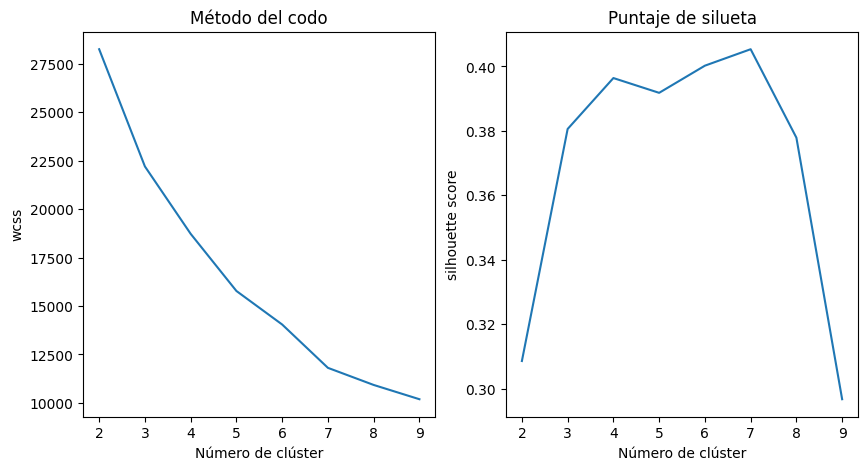

In [ ]:
silueta_score=[] # puntaje de silueta
wcss =[] #
n_clusters= range( 2,10)
for k in n_clusters:
  k_means=KMeans(k, random_state=1017923112)
  k_means.fit(scaled_features)
  wcss.append(k_means.inertia_ )
  silueta = silhouette_score(scaled_features, k_means.labels_)
  silueta_score.append(silueta)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(n_clusters,wcss)
axs[0].set_title("Método del codo")
axs[0].set_xlabel("Número de clúster" )
axs[0].set_ylabel("wcss" )
axs[1].plot( n_clusters,silueta_score)
axs[1].set_title("Puntaje de silueta")
axs[1].set_xlabel("Número de clúster" )
axs[1].set_ylabel("silhouette score" )
plt.show()

El metodo del codo nos muestra un ligero punto de inflexión al tener **5 y 7 clusteres**.

El Puntaje de Silueta nos muestra que de 5 a 7 clusteres obtenemos un puntaje alto, siendo mas alto en **7 Clusters**.

Para tener un punto medio, voy a seleccionar 6 Clusters.

In [ ]:
k_means=KMeans(6, random_state = 1017923113)
k_means.fit(scaled_features )
data1["labels_k_means"]= k_means.labels_
data1["labels_k_means"] = data1["labels_k_means"].astype(str)
data1["labels_k_means"].value_counts()

,count
labels_k_means,
0,1403
2,1032
3,818
1,671
4,373
5,4


### Hierarchical Clustering

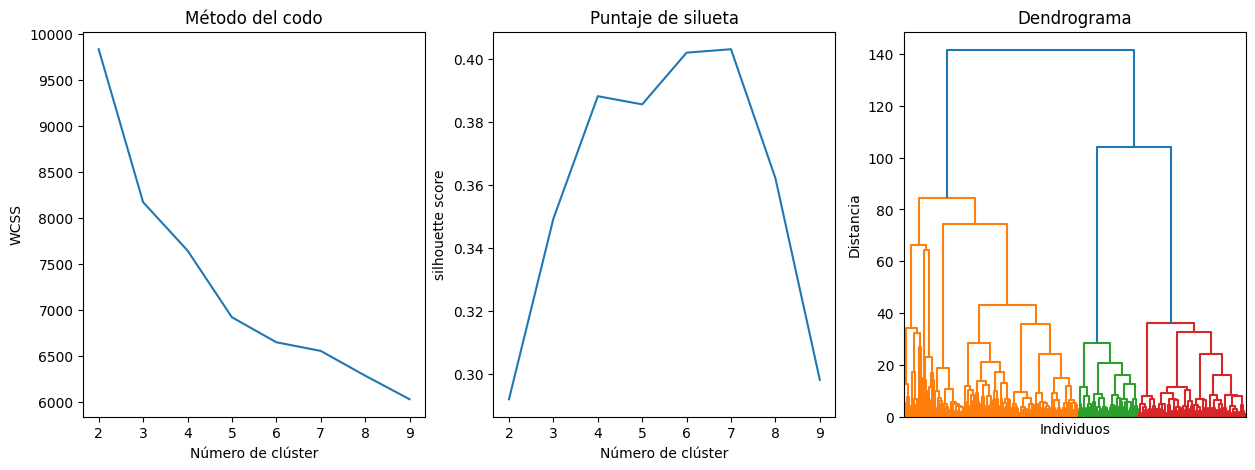

In [ ]:
silueta =[]
wcss =[]
n_cluster=range(2,10)
for i in n_cluster:
  jerarquico = AgglomerativeClustering(i)
  jerarquico.fit(scaled_features)
  scaled_temp= pd.DataFrame(scaled_features)
  scaled_temp["labels"]=jerarquico.labels_
  centros= scaled_temp.groupby("labels").mean()  # obteniendo centros
  argmin, distance =pairwise_distances_argmin_min(scaled_features,centros  )  # obteniendo distancias
  wcss.append(np.sum(distance) )
  score = silhouette_score(scaled_features,jerarquico.labels_ )
  silueta.append(score)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot( (n_cluster), wcss  )
axes[0].set_ylabel("WCSS")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clúster" )
axes[1].plot( (n_cluster), silueta  )
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Puntaje de silueta")
axes[1].set_xlabel("Número de clúster" )

# visualización clustering jerarquico
dist_matrix = linkage(scaled_features, method='ward')
# Visualizar el dendrograma
dendrogram(dist_matrix,no_labels=True)
axes[2].set_title('Dendrograma')
axes[2].set_xlabel('Individuos')
axes[2].set_ylabel('Distancia')
plt.show()

El metodo del codo nos muestra varios puntos de inflexión: **Al tener 3, 5 y 6 Clusters.**

El puntaje de silueta nos indica que al tener **5 Clusters** obtenemos un excelente puntaje, pero tambien con **6 o 7 Clusters** obtenemos un buen puntaje.

Al interpretar el dendograma, pensaría que **3 Clusters** seria lo mas apropiado

En conclusion, voy a seleccionar **5** como numero de clusters.

In [ ]:
hc=AgglomerativeClustering(5)
hc.fit(scaled_features )
data1["labels_hc"]= hc.labels_
data1["labels_hc"] = data1["labels_hc"].astype(str)
data1["labels_hc"].value_counts()

,count
labels_hc,
0,1814
2,1253
4,742
3,330
1,162


# Interpretacion de Resultados

### K-Means

labels_k_means
1    0.314578
5    0.237154
0    0.175076
4    0.160195
3    0.058591
2    0.054406
Name: proportion, dtype: float64


<Axes: xlabel='labels_k_means', ylabel='proportion'>

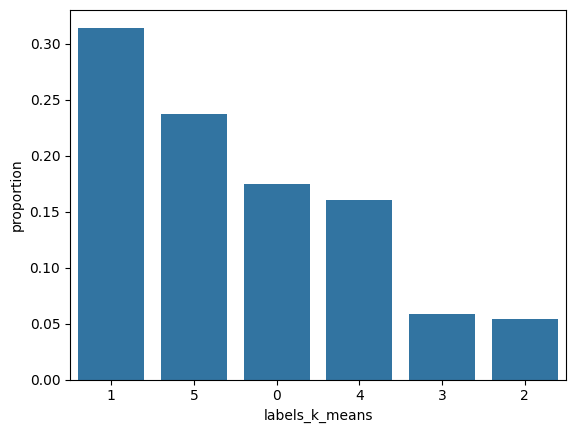

In [ ]:
print(data1["labels_k_means"].value_counts(normalize=True))
sns.barplot(data1["labels_k_means"].value_counts(normalize=True) )

Podemos observar que en el cluster #1 se encuentran 31% de los registros, mientras que el Cluster #3 tiene 5.8% y el #2 tiene 5.4%.

### Hierarchical Clustering

labels_hc
0    0.421762
2    0.291328
4    0.172518
3    0.076726
1    0.037666
Name: proportion, dtype: float64


<Axes: xlabel='labels_hc', ylabel='proportion'>

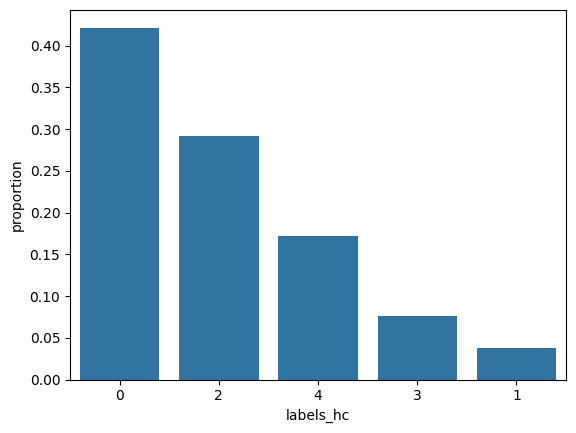

In [ ]:
print(data1["labels_hc"].value_counts(normalize=True))
sns.barplot(data1["labels_hc"].value_counts(normalize=True) )

Para la selección de algoritmo, pienso que **K-Means** sería mas apropiado para el problema

# K-Means

In [ ]:
data1.head()

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE,M2Price,NumBedBath,TYPE_Co-op for sale,TYPE_Condo for sale,TYPE_Other,labels_k_means,labels_hc
0,315000,2,2.0,1400.000000,40.761255,-73.974483,225.000000,4.0,False,True,False,0,4
2,260000,4,2.0,2015.000000,40.541805,-74.196109,129.032258,6.0,False,False,True,4,0
3,69000,3,1.0,445.000000,40.761398,-73.974613,155.056180,4.0,False,True,False,0,4
5,690000,5,2.0,4004.000000,40.674363,-73.958725,172.327672,7.0,False,False,True,5,0
6,899500,2,2.0,2184.207862,40.809448,-73.946777,411.819779,4.0,False,True,False,0,4


## Graficos con Variables de Interes

### PRICE

In [ ]:
px.box(data1, x='labels_k_means', y='PRICE',color="labels_k_means",
       #points=False, # No muestra los puntos atípicos extendiendo las barras
             title='PRICE: Boxplot por clúster')

Podemos ver que los cluster 2 y 3, son los que tienen un precio medio mayor. No sobra resaltar que estos dos cluster son los que menos registros tienen.

El cluster #3, es el que mayor precio medio tiene. Con un precio maximo de 9.99 Millones de Dolares, medio de 5.22 Millones y minimo de 2.79 Millones.

Los cluster #0, #4, y #5 tienen una media muy parecida: entre 750K y 900K.

El cluster #1 contiene las propiedades mas baratas, con una media de 399K.

### Ubicación

In [ ]:
fig = px.scatter_mapbox(data1, lat="LATITUDE", lon="LONGITUDE", color="labels_k_means")
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

Despues de analizar el precio, tenemos una mejor vista respecto a las propiedades por ubicación. Al trazarlas en un mapa, podemos ver que las propiedades que pertenecen al cluster #3 estan en cerca a Central Park, Manhattan. Por esto es que tienen un precio elevado y son las propiedades mas escasas.

El cluster #2, que tambien tenía un precio medio alto,pero menos registros, tiene propiedades mas repartidas que el Cluster #3.

Este cluster tiene propiedades en Manhattan, Queens, Brooklyn, etc.

El cluster #1, era el cluster que mas propiedades tenía y que tenían un precio medio menor.

Este cluster tiene propiedades demasiado repartidas por todo el mapa

In [ ]:
data1['TYPE'] = datos['TYPE']

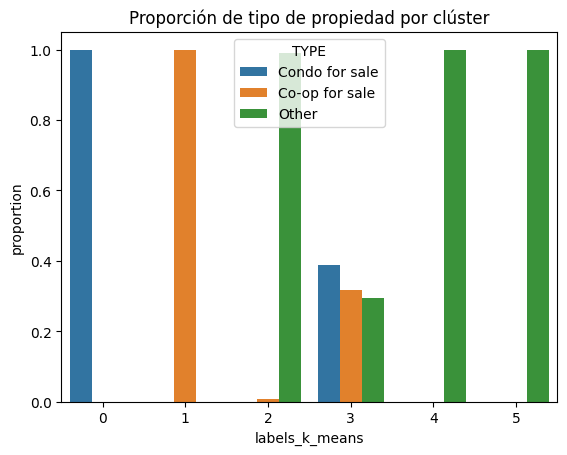

In [ ]:
tabla_frecuencia_relacion= data1.groupby('labels_k_means')['TYPE'].value_counts(normalize=True)
sns.barplot(data=tabla_frecuencia_relacion.reset_index(), x='labels_k_means', y='proportion', hue='TYPE')
plt.title('Proporción de tipo de propiedad por clúster')
plt.show()

Respecto a los clusters 2 y 3 (las propiedades mas costosas), podemos ver que el cluster #3 tiene todos los tipos de propiedad: Cooperativas, Condominios, y otros. Mientras que el cluster #2, tiene muy pocas cooperativas y de resto solamente tiene Otros.

Los cluster 4 y 5 tienen solamente otros

El cluster 0 tiene solamente condos y el cluster 1 tiene solamente propiedades cooperativas.

In [ ]:
fig = px.scatter_mapbox(data1, lat="LATITUDE", lon="LONGITUDE", color="TYPE")
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

Podemos ver que la mayoría de Condos estan en Manhattan, aunque tambien hay Condos repartidos por todo el mapa.

Respecto a las propiedades cooperativas, estan muy repartidas por todo el mapa pero tambien hay un foco en Manhattan.

Con las otras propiedades, que no tienen un tipo especifico, no vemos ningun tipo de foco ya que estan completamente repartidas.

# Recomendaciónes

Si fuera encargado esta agencia de propiedad raiz, me concentraría en realizar otro tipo de campañas de marketing para las propiedades dentro del cluster 2 y 3.

Estas son las propiedades mas costosas, por lo que le estaría apuntando a otro tipo de publico completamente distinto con unos niveles de ingresos mucho mayores.

Estas campañas de marketing dirigidas a estos cluster permiten atraer clientes potenciales, ya que debido a su precio son propiedades mas dificiles de vender.

En cambio, las propiedades dentro de los otros cluster son principalmente para otro tipo de clientes con ingresos mucho menores. Por esto, las estrategias deben ser completamente distintas.